# GDV Diagnostic Notebook

Tests GDV behaviour on controlled 2-D distributions:
- **Perfectly separable** clusters
- **Completely overlapping** clusters
- **Balanced** (equal class sizes) vs **imbalanced** (crude size mismatch)

We also decompose the result into `intra`, `inter`, and `gdv` and
inspect the per-class coefficient weights to understand the sign anomaly.

In [1]:
%matplotlib inline
import sys, os
sys.path.insert(0, os.path.abspath(".."))

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from itertools import product

from metrics.gdv import compute_gdv_metric, _mean_intra_inter

rng = np.random.default_rng(42)

## 1  Distribution factories

In [2]:
def make_separable(K: int, n_per_class: int | list[int], spread: float = 0.3, gap: float = 4.0) -> tuple:
    """
    K clusters arranged on a circle of radius `gap`,
    each with isotropic Gaussian spread `spread`.
    n_per_class: int (same for all) or list of ints.
    """
    if isinstance(n_per_class, int):
        n_per_class = [n_per_class] * K
    angles = np.linspace(0, 2 * np.pi, K, endpoint=False)
    centres = gap * np.stack([np.cos(angles), np.sin(angles)], axis=1)
    X, y = [], []
    for k, (c, n) in enumerate(zip(centres, n_per_class)):
        pts = rng.normal(loc=c, scale=spread, size=(n, 2))
        X.append(pts)
        y.extend([k] * n)
    return np.vstack(X), np.array(y)


def make_overlap(K: int, n_per_class: int | list[int]) -> tuple:
    """
    All K clusters share the SAME isotropic Gaussian (mean=0, std=1).
    Labels are assigned sequentially so GDV should be ~0.
    """
    if isinstance(n_per_class, int):
        n_per_class = [n_per_class] * K
    N = sum(n_per_class)
    X = rng.normal(size=(N, 2))
    y = np.concatenate([np.full(n, k) for k, n in enumerate(n_per_class)])
    return X, y


def plot_dist(ax, X, y, title):
    for k in np.unique(y):
        ax.scatter(X[y == k, 0], X[y == k, 1], s=10, alpha=0.6, label=f"c{k}")
    ax.set_title(title, fontsize=9)
    ax.set_aspect("equal")
    ax.legend(fontsize=6, markerscale=2)

## 2  Coefficient weight analysis

Before running numbers, let's inspect the **theoretical weights** that `intra` and `inter`
receive in `compute_gdv_metric` as K grows.

In [3]:
print(f"{'K':>4} | {'w_intra = 1/K':>14} | {'w_inter = 2/(K(K-1))':>20} | {'ratio w_intra/w_inter':>22}")
print("-" * 68)
for K in range(2, 13):
    if K == 2:
        # K==2 formula: (intra - inter)/sqrt(D)  =>  w_intra=1, w_inter=1
        wi, we = 1.0, 1.0
    else:
        wi = 1 / K
        we = 2 / (K * (K - 1))
    ratio = wi / we
    print(f"{K:>4} | {wi:>14.4f} | {we:>20.4f} | {ratio:>22.3f}")

   K |  w_intra = 1/K | w_inter = 2/(K(K-1)) |  ratio w_intra/w_inter
--------------------------------------------------------------------
   2 |         1.0000 |               1.0000 |                  1.000
   3 |         0.3333 |               0.3333 |                  1.000
   4 |         0.2500 |               0.1667 |                  1.500
   5 |         0.2000 |               0.1000 |                  2.000
   6 |         0.1667 |               0.0667 |                  2.500
   7 |         0.1429 |               0.0476 |                  3.000
   8 |         0.1250 |               0.0357 |                  3.500
   9 |         0.1111 |               0.0278 |                  4.000
  10 |         0.1000 |               0.0222 |                  4.500
  11 |         0.0909 |               0.0182 |                  5.000
  12 |         0.0833 |               0.0152 |                  5.500


**Key observation:** for K ≥ 4, `w_intra > w_inter`. For large K the intra term
increasingly dominates, so even large inter distances may not outweigh tight intra
distances and the sign can flip to positive (→ misleadingly small positive value near 0).

## 3  Balanced clusters — varying K

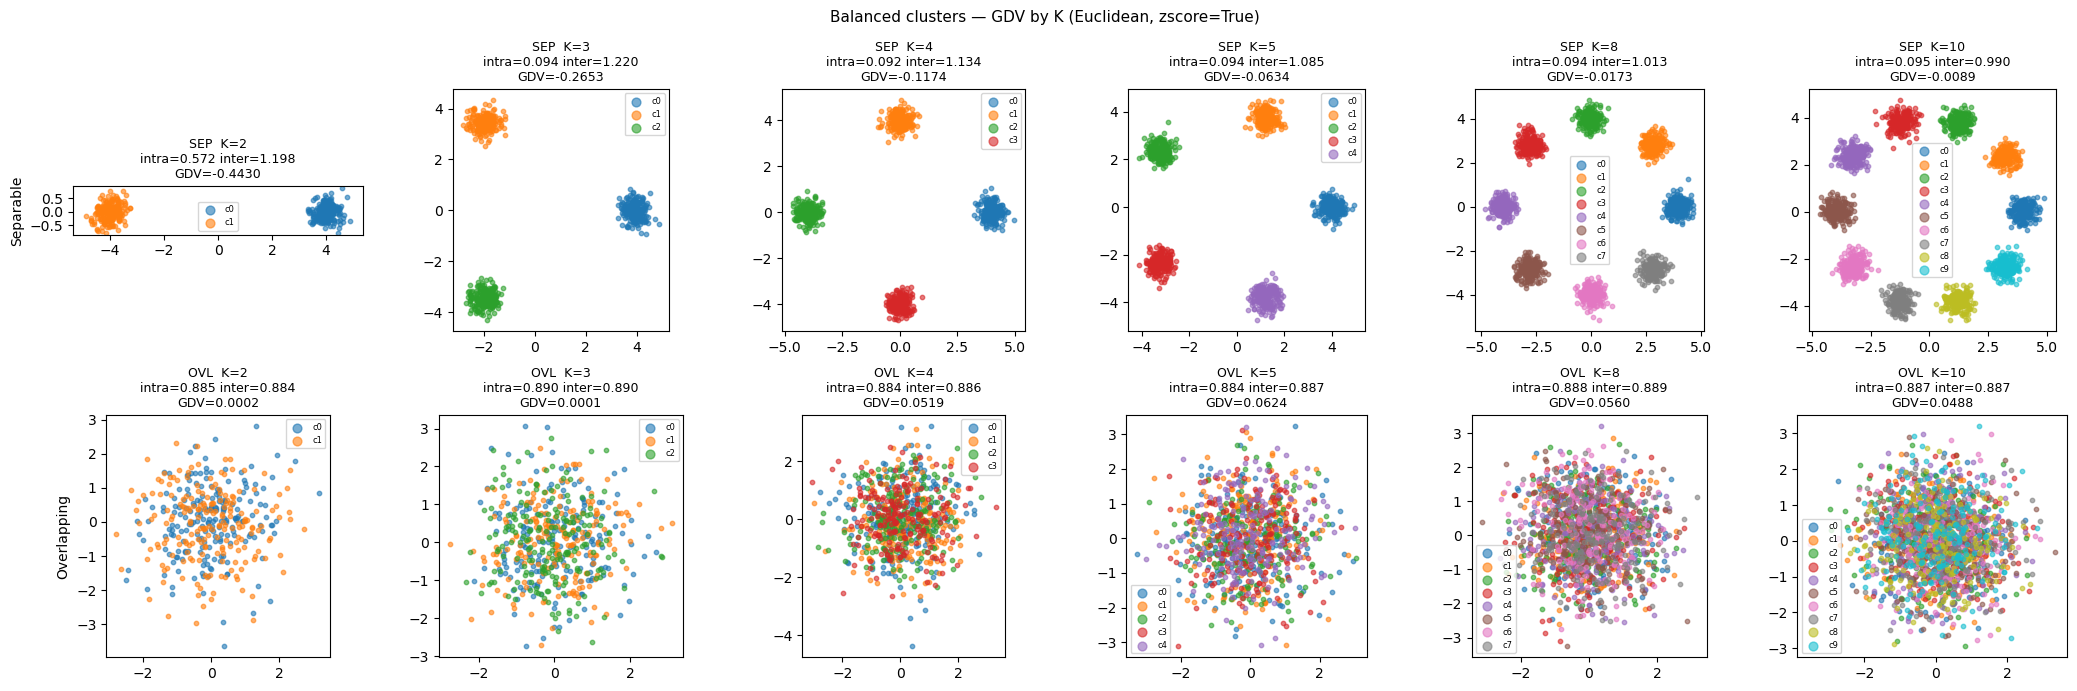

In [4]:
K_values = [2, 3, 4, 5, 8, 10]
N_PER_CLASS = 200
SPREAD = 0.3
GAP = 4.0

fig, axes = plt.subplots(2, len(K_values), figsize=(3.5 * len(K_values), 7))

rows_sep, rows_ov = [], []

for col, K in enumerate(K_values):
    # --- Separable ---
    X_s, y_s = make_separable(K, N_PER_CLASS, spread=SPREAD, gap=GAP)
    res_s = compute_gdv_metric(X_s, y_s, metric="euclidean", zscore=True)
    plot_dist(axes[0, col], X_s, y_s, f"SEP  K={K}\nintra={res_s['intra']:.3f} inter={res_s['inter']:.3f}\nGDV={res_s['gdv']:.4f}")
    rows_sep.append({"K": K, **res_s})

    # --- Overlap ---
    X_o, y_o = make_overlap(K, N_PER_CLASS)
    res_o = compute_gdv_metric(X_o, y_o, metric="euclidean", zscore=True)
    plot_dist(axes[1, col], X_o, y_o, f"OVL  K={K}\nintra={res_o['intra']:.3f} inter={res_o['inter']:.3f}\nGDV={res_o['gdv']:.4f}")
    rows_ov.append({"K": K, **res_o})

axes[0, 0].set_ylabel("Separable", fontsize=10)
axes[1, 0].set_ylabel("Overlapping", fontsize=10)
plt.suptitle("Balanced clusters — GDV by K (Euclidean, zscore=True)", fontsize=11)
plt.tight_layout()
plt.show()

In [5]:
import pandas as pd

df_sep = pd.DataFrame(rows_sep).set_index("K")
df_ov  = pd.DataFrame(rows_ov).set_index("K")

print("=== Separable ===")
print(df_sep[["intra", "inter", "gdv"]].to_string())
print("\n=== Overlapping ===")
print(df_ov[["intra", "inter", "gdv"]].to_string())
print("\n=== GDV(sep) - GDV(overlap) ===")
print((df_sep["gdv"] - df_ov["gdv"]).to_string())

=== Separable ===
       intra     inter       gdv
K                               
2   0.571752  1.198186 -0.442956
3   0.094453  1.220190 -0.265339
4   0.092391  1.134364 -0.117353
5   0.094261  1.084733 -0.063372
8   0.093641  1.013193 -0.017310
10  0.094780  0.989944 -0.008854

=== Overlapping ===
       intra     inter       gdv
K                               
2   0.884604  0.884302  0.000213
3   0.890224  0.889676  0.000129
4   0.884189  0.886283  0.051854
5   0.884289  0.886699  0.062358
8   0.888082  0.888970  0.056046
10  0.887325  0.886723  0.048810

=== GDV(sep) - GDV(overlap) ===
K
2    -0.443169
3    -0.265468
4    -0.169208
5    -0.125730
8    -0.073356
10   -0.057663


## 4  Balanced — GDV sign as a function of K (line plot)

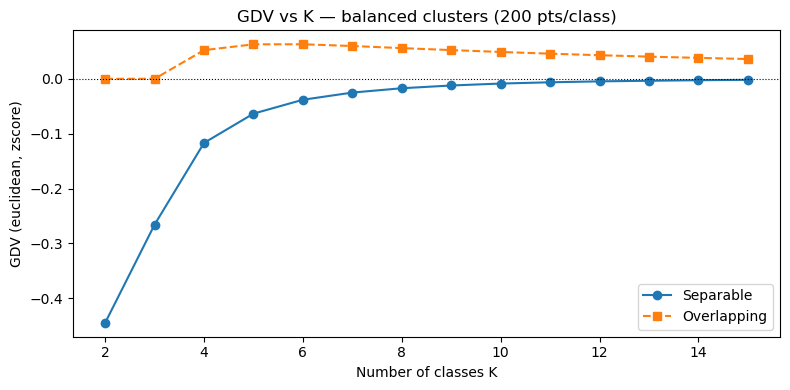

In [6]:
K_range = list(range(2, 16))
gdv_sep, gdv_ov = [], []
for K in K_range:
    X_s, y_s = make_separable(K, 200, spread=SPREAD, gap=GAP)
    gdv_sep.append(compute_gdv_metric(X_s, y_s)["gdv"])
    X_o, y_o = make_overlap(K, 200)
    gdv_ov.append(compute_gdv_metric(X_o, y_o)["gdv"])

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(K_range, gdv_sep, "o-", label="Separable")
ax.plot(K_range, gdv_ov, "s--", label="Overlapping")
ax.axhline(0, color="k", lw=0.8, ls=":")
ax.set_xlabel("Number of classes K")
ax.set_ylabel("GDV (euclidean, zscore)")
ax.set_title("GDV vs K — balanced clusters (200 pts/class)")
ax.legend()
plt.tight_layout()
plt.show()

## 5  Imbalanced clusters — crude size mismatch

We now keep K=5 and vary the ratio of the largest to smallest class.
Both `macro` and `micro` weighting are tested.

In [7]:
K = 5
BASE = 50
# imbalance ratios: multiplier applied to class 0
ratios = [1, 2, 5, 10, 20, 50]

rows = []
for r in ratios:
    sizes = [BASE * r] + [BASE] * (K - 1)
    for label, maker in [("sep", make_separable), ("ovl", make_overlap)]:
        X, y = maker(K, sizes, spread=SPREAD, gap=GAP) if label == "sep" else maker(K, sizes)
        for w in ["macro", "micro"]:
            res = compute_gdv_metric(X, y, metric="euclidean", weighting=w, zscore=True)
            rows.append({
                "ratio": r,
                "distribution": label,
                "weighting": w,
                "n_class0": sizes[0],
                "intra": res["intra"],
                "inter": res["inter"],
                "gdv": res["gdv"],
            })

df_imb = pd.DataFrame(rows)
print(df_imb.to_string(index=False))

 ratio distribution weighting  n_class0    intra    inter       gdv
     1          sep     macro        50 0.095785 1.084680 -0.063152
     1          sep     micro        50 0.095785 1.084680 -0.063152
     1          ovl     macro        50 0.891986 0.886336  0.063472
     1          ovl     micro        50 0.891986 0.886336  0.063472
     2          sep     macro       100 0.099817 1.109129 -0.064311
     2          sep     micro       100 0.097848 1.101062 -0.064019
     2          ovl     macro       100 0.901779 0.901185  0.063807
     2          ovl     micro       100 0.887792 0.896602  0.062153
     5          sep     macro       250 0.110075 1.260095 -0.073535
     5          sep     micro       250 0.108949 1.216894 -0.070640
     5          ovl     macro       250 0.874934 0.882176  0.061355
     5          ovl     micro       250 0.887610 0.882854  0.063100
    10          sep     macro       500 0.125485 1.515023 -0.089382
    10          sep     micro       500 0.125973

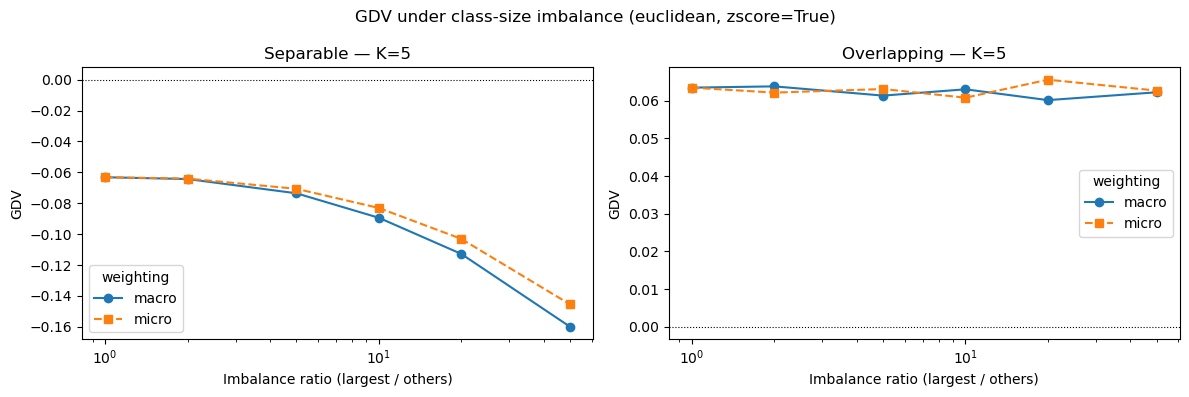

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=False)

for ax, dist_label in zip(axes, ["sep", "ovl"]):
    sub = df_imb[df_imb["distribution"] == dist_label]
    for w, style in [("macro", "o-"), ("micro", "s--")]:
        d = sub[sub["weighting"] == w]
        ax.plot(d["ratio"], d["gdv"], style, label=w)
    ax.axhline(0, color="k", lw=0.8, ls=":")
    ax.set_xlabel("Imbalance ratio (largest / others)")
    ax.set_ylabel("GDV")
    ax.set_title(f"{'Separable' if dist_label == 'sep' else 'Overlapping'} — K={K}")
    ax.legend(title="weighting")
    ax.set_xscale("log")

plt.suptitle("GDV under class-size imbalance (euclidean, zscore=True)")
plt.tight_layout()
plt.show()

## 6  Sanity check: raw intra vs inter with z-score ON and OFF

z-score rescales each dimension independently to unit variance and then multiplies by 0.5.
With only 2 dims this is benign, but in high-D it can distort distances
if the data already has very different per-dim variances.

In [9]:
K = 5
X_s, y_s = make_separable(K, 200, spread=SPREAD, gap=GAP)
X_o, y_o = make_overlap(K, 200)

print(f"{'':20} | {'zscore=True':>30} | {'zscore=False':>30}")
print(f"{'':20} | {'intra':>8} {'inter':>8} {'gdv':>10} | {'intra':>8} {'inter':>8} {'gdv':>10}")
print("-" * 84)
for name, X, y in [("Separable", X_s, y_s), ("Overlapping", X_o, y_o)]:
    r1 = compute_gdv_metric(X, y, zscore=True)
    r0 = compute_gdv_metric(X, y, zscore=False)
    print(f"{name:20} | {r1['intra']:8.4f} {r1['inter']:8.4f} {r1['gdv']:10.6f} | {r0['intra']:8.4f} {r0['inter']:8.4f} {r0['gdv']:10.6f}")

                     |                    zscore=True |                   zscore=False
                     |    intra    inter        gdv |    intra    inter        gdv
------------------------------------------------------------------------------------
Separable            |   0.0943   1.0847  -0.063362 |   0.5377   6.1825  -0.361134
Overlapping          |   0.8832   0.8849   0.062325 |   1.7974   1.8010   0.126837


## 7  Summary & Diagnosis

In [10]:
print("""DIAGNOSIS SUMMARY
=================

Coefficient weights in compute_gdv_metric:
  K==2  : GDV = (intra - inter) / sqrt(D)           -> w_intra == w_inter  (balanced)
  K==3  : GDV = (1/3)*intra - (1/3)*inter            -> w_intra == w_inter  (balanced)
  K>=4  : w_intra = 1/K,  w_inter = 2/(K(K-1))
           => w_intra/w_inter = (K-1)/2
           For K=4 -> ratio=1.5,  K=5 -> 2.0,  K=10 -> 4.5

Consequence:
  For K>=4 the intra term is OVER-WEIGHTED relative to inter.
  Even for perfectly separated clusters (intra small, inter large),
  the scaling means the formula can still produce a small POSITIVE value
  instead of the expected strong NEGATIVE value.

The fix (one option) is to normalise both terms by the same factor:
  GDV = (1/sqrt(D)) * (intra/K - inter / C(K,2))
where C(K,2) = K*(K-1)/2 is the number of class pairs,
which gives w_intra = 1/K and w_inter = 1/C(K,2) = 2/(K*(K-1)) — same as now.

The REAL fix is likely to weight inter by the same denominator type as intra,
e.g. both divided by K:
  GDV = (1/sqrt(D)) * (intra - inter) / K   <-- simple symmetric version
or to use a known clustering metric like the normalised version.
""")

DIAGNOSIS SUMMARY

Coefficient weights in compute_gdv_metric:
  K==2  : GDV = (intra - inter) / sqrt(D)           -> w_intra == w_inter  (balanced)
  K==3  : GDV = (1/3)*intra - (1/3)*inter            -> w_intra == w_inter  (balanced)
  K>=4  : w_intra = 1/K,  w_inter = 2/(K(K-1))
           => w_intra/w_inter = (K-1)/2
           For K=4 -> ratio=1.5,  K=5 -> 2.0,  K=10 -> 4.5

Consequence:
  For K>=4 the intra term is OVER-WEIGHTED relative to inter.
  Even for perfectly separated clusters (intra small, inter large),
  the scaling means the formula can still produce a small POSITIVE value
  instead of the expected strong NEGATIVE value.

The fix (one option) is to normalise both terms by the same factor:
  GDV = (1/sqrt(D)) * (intra/K - inter / C(K,2))
where C(K,2) = K*(K-1)/2 is the number of class pairs,
which gives w_intra = 1/K and w_inter = 1/C(K,2) = 2/(K*(K-1)) — same as now.

The REAL fix is likely to weight inter by the same denominator type as intra,
e.g. both divided by K: